In [1]:
import json
import pandas as pd
from pathlib import Path

def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

def detect_timestamp_mode(df, file_path=None):
    # Content-based detection
    if "word_timestamps" in df.columns:
        has_ts = df["word_timestamps"].apply(
            lambda x: isinstance(x, list)
        ).any()
        if has_ts:
            return "timestamps"
    
    # Optional filename fallback
    if file_path is not None:
        name = Path(file_path).stem.lower()
        if "timestamp" in name or "wordts" in name or "ts" in name:
            return "timestamps"
    
    return "no_timestamps"

def load_all_predictions(folder):
    dfs = []
    
    for file in Path(folder).glob("*.jsonl"):
        df = load_jsonl(file)
        
        # Base model name
        if "model" not in df.columns:
            df["model"] = file.stem
        
        # Add timestamp variant
        ts_mode = detect_timestamp_mode(df, file)
        df["timestamp_mode"] = ts_mode
        
        # Combined label for comparison
        df["model_variant"] = df["model"] + " | " + df["timestamp_mode"]
        
        dfs.append(df)
    
    return pd.concat(dfs, ignore_index=True)

df = load_all_predictions("../data/processed/asr_predictions/")
df[["model", "timestamp_mode", "model_variant"]].drop_duplicates().sort_values(["model", "timestamp_mode"])

,model,timestamp_mode,model_variant
0,canary:nvidia/canary-1b-v2,no_timestamps,canary:nvidia/canary-1b-v2 | no_timestamps
20000,conformer_ctc:stt_en_conformer_ctc_large,no_timestamps,conformer_ctc:stt_en_conformer_ctc_large | no_...
40000,speechbrain:speechbrain/asr-crdnn-rnnlm-libris...,no_timestamps,speechbrain:speechbrain/asr-crdnn-rnnlm-libris...
60000,wav2vec2:facebook/wav2vec2-large-960h-lv60-self,no_timestamps,wav2vec2:facebook/wav2vec2-large-960h-lv60-sel...
120000,whisper:base,no_timestamps,whisper:base | no_timestamps
140000,whisper:base,timestamps,whisper:base | timestamps
160000,whisper:large-v3,no_timestamps,whisper:large-v3 | no_timestamps
180000,whisper:large-v3,timestamps,whisper:large-v3 | timestamps
200000,whisper:medium,no_timestamps,whisper:medium | no_timestamps
220000,whisper:medium,timestamps,whisper:medium | timestamps


In [2]:
import re
from jiwer import wer, mer, wil, cer

FILLER_WORDS = {
    "uh", "um", "mm", "hmm", "hm", "mhm", "mmhm", "mmhmm",
    "ah", "eh", "er", "erm", "huh", "uhu", "uhuh", "mmm"
}

def filter_fillers(text):
    text = str(text).lower()
    text = text.replace("-", " ")
    text = re.sub(r"[^\w\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    words = [w for w in text.split() if w not in FILLER_WORDS]
    return " ".join(words)


def compute_metric_block(group, ref_col, hyp_col, prefix):
    refs = group[ref_col].tolist()
    hyps = group[hyp_col].tolist()

    return pd.Series({
        f"{prefix}_wer": wer(refs, hyps),
        f"{prefix}_mer": mer(refs, hyps),
        f"{prefix}_wil": wil(refs, hyps),
        f"{prefix}_cer": cer(" ".join(refs), " ".join(hyps)),
    })

n_variants = df["model_variant"].nunique()
common_segments = (
    df.groupby("segment_id")["model_variant"]
      .nunique()
      .loc[lambda x: x == n_variants]
      .index
)
df = df[df["segment_id"].isin(common_segments)].copy()

# Raw text columns
df["ref_raw"] = df["reference_text"].astype(str)
df["hyp_raw"] = df["asr_text"].astype(str)

# Filtered text columns
df["ref_filtered"] = df["reference_text"].apply(filter_fillers)
df["hyp_filtered"] = df["asr_text"].apply(filter_fillers)

# Remove rows where both become empty after filtering
df_eval = df[
    ~((df["ref_filtered"] == "") & (df["hyp_filtered"] == ""))
].copy()

raw_summary = df_eval.groupby(["model", "timestamp_mode", "model_variant"]).apply(
    lambda g: compute_metric_block(g, "ref_raw", "hyp_raw", "raw")
)

filtered_summary = df_eval.groupby(["model", "timestamp_mode", "model_variant"]).apply(
    lambda g: compute_metric_block(g, "ref_filtered", "hyp_filtered", "filtered")
)

meta_summary = df_eval.groupby(["model", "timestamp_mode", "model_variant"]).agg(
    mean_latency_ms=("latency_ms", "mean"),
    num_segments=("segment_id", "count"),
)

summary = pd.concat([raw_summary, filtered_summary, meta_summary], axis=1)
summary = summary.sort_values("filtered_wer")

print(summary)


                                                                                                                       raw_wer  \
model                                              timestamp_mode model_variant                                                  
whisper:large-v3                                   timestamps     whisper:large-v3 | timestamps                       0.533958   
                                                   no_timestamps  whisper:large-v3 | no_timestamps                    0.534645   
canary:nvidia/canary-1b-v2                         no_timestamps  canary:nvidia/canary-1b-v2 | no_timestamps          0.538145   
whisper:medium                                     timestamps     whisper:medium | timestamps                         0.538823   
                                                   no_timestamps  whisper:medium | no_timestamps                      0.541912   
whisper:small                                      timestamps     whisper:small | timestam

In [7]:
df_table = summary.reset_index().copy()

# Keep only models WITHOUT timestamps
df_no_ts = df_table[df_table["timestamp_mode"] == "no_timestamps"].copy()

# Select relevant columns
accuracy_table = df_no_ts[
    [
        "model_variant",
        "raw_wer",
        "filtered_wer",
        "raw_mer",
        "filtered_mer",
        "raw_wil",
        "filtered_wil",
        "raw_cer",
        "filtered_cer",
        "mean_latency_ms",
        "num_segments",
    ]
].copy()

# Optional: round for readability
for col in [
    "raw_wer", "filtered_wer",
    "raw_mer", "filtered_mer",
    "raw_wil", "filtered_wil",
    "raw_cer", "filtered_cer",
]:
    accuracy_table[col] = accuracy_table[col].round(4)

accuracy_table["mean_latency_ms"] = accuracy_table["mean_latency_ms"].round(1)

# Sort by best accuracy
accuracy_table = accuracy_table.sort_values("filtered_wer").reset_index(drop=True)

accuracy_table

,model_variant,raw_wer,filtered_wer,raw_mer,filtered_mer,raw_wil,filtered_wil,raw_cer,filtered_cer,mean_latency_ms,num_segments
0,whisper:large-v3 | no_timestamps,0.5346,0.3021,0.5208,0.2823,0.6860,0.3736,0.2672,0.2109,242.3,19105
1,canary:nvidia/canary-1b-v2 | no_timestamps,0.5381,0.3076,0.5243,0.2876,0.6926,0.3884,0.2670,0.2116,78.0,19369
2,whisper:medium | no_timestamps,0.5419,0.3138,0.5265,0.2932,0.6907,0.3885,0.2750,0.2184,179.9,18928
3,whisper:small | no_timestamps,0.5488,0.3252,0.5316,0.3019,0.6987,0.4034,0.2791,0.2233,127.3,18941
4,conformer_ctc:stt_en_conformer_ctc_large | no_...,0.5101,0.3594,0.4999,0.3404,0.6532,0.4695,0.2951,0.2257,23.7,19007
5,whisper:base | no_timestamps,0.5653,0.3609,0.5469,0.3334,0.7207,0.4569,0.2955,0.2411,91.2,18800
6,whisper:tiny | no_timestamps,0.5931,0.4060,0.5718,0.3712,0.7521,0.5135,0.3174,0.2660,90.3,18962
7,wav2vec2:facebook/wav2vec2-large-960h-lv60-sel...,0.9987,0.4280,0.9877,0.4009,0.9998,0.5643,0.8225,0.2463,23.7,18736
8,speechbrain:speechbrain/asr-crdnn-rnnlm-libris...,1.0849,0.7530,0.9914,0.6293,0.9999,0.8064,0.8857,0.5234,243.7,19553


In [8]:
min_chars = 20  # change this threshold as needed

df_len = df.copy()
df_len["ref_num_chars"] = df_len["reference_text"].astype(str).str.len()
df_len["hyp_num_chars"] = df_len["asr_text"].astype(str).str.len()

# keep only segments with reference length >= min_chars
df_len = df_len[df_len["ref_num_chars"] >= min_chars].copy()

print(f"Segments kept: {len(df_len)} / {len(df)}")

Segments kept: 173504 / 320000


In [9]:
n_variants = df_len["model_variant"].nunique()

common_segments_len = (
    df_len.groupby("segment_id")["model_variant"]
          .nunique()
          .loc[lambda x: x == n_variants]
          .index
)

df_len = df_len[df_len["segment_id"].isin(common_segments_len)].copy()

print(f"Comparable segments kept: {len(df_len)}")

Comparable segments kept: 173504


In [10]:
df_len["ref_raw"] = df_len["reference_text"].astype(str)
df_len["hyp_raw"] = df_len["asr_text"].astype(str)

df_len["ref_filtered"] = df_len["reference_text"].apply(filter_fillers)
df_len["hyp_filtered"] = df_len["asr_text"].apply(filter_fillers)

# remove rows where both are empty after filtering
df_len_eval = df_len[
    ~((df_len["ref_filtered"] == "") & (df_len["hyp_filtered"] == ""))
].copy()

In [11]:
group_cols = ["model", "timestamp_mode", "model_variant"]

raw_summary_len = df_len_eval.groupby(group_cols).apply(
    lambda g: compute_metric_block(g, "ref_raw", "hyp_raw", "raw")
)

filtered_summary_len = df_len_eval.groupby(group_cols).apply(
    lambda g: compute_metric_block(g, "ref_filtered", "hyp_filtered", "filtered")
)

meta_summary_len = df_len_eval.groupby(group_cols).agg(
    mean_latency_ms=("latency_ms", "mean"),
    num_segments=("segment_id", "count"),
    mean_ref_chars=("ref_num_chars", "mean"),
)

summary_len = pd.concat(
    [raw_summary_len, filtered_summary_len, meta_summary_len],
    axis=1
).sort_values("filtered_wer")

summary_len

raw_wer  \
model                                              timestamp_mode model_variant                                                  
whisper:large-v3                                   timestamps     whisper:large-v3 | timestamps                       0.490989   
                                                   no_timestamps  whisper:large-v3 | no_timestamps                    0.491534   
canary:nvidia/canary-1b-v2                         no_timestamps  canary:nvidia/canary-1b-v2 | no_timestamps          0.492795   
whisper:medium                                     timestamps     whisper:medium | timestamps                         0.495725   
whisperx:small                                     timestamps     whisperx:small | timestamps                         0.493047   
whisper:medium                                     no_timestamps  whisper:medium | no_timestamps                      0.498076   
whisper:small                                      timestamps     whisper:small | timestamps                          0.500277   
                                                   no_timestamps  whisper:small | no_timestamps                       0.501857   
whisper:base                                       timestamps     whisper:base | timestamps                           0.521589   
                                                   no_timestamps  whisper:base | no_timestamps                        0.521933   
conformer_ctc:stt_en_conformer_ctc_large           no_timestamps  conformer_ctc:stt_en_conformer_ctc_large | no_t...  0.468394   
whisper:tiny                                       timestamps     whisper:tiny | timestamps                           0.548937   
                                                   no_timestamps  whisper:tiny | no_timestamps                        0.550408   
wav2vec2:facebook/wav2vec2-large-960h-lv60-self    no_timestamps  wav2vec2:facebook/wav2vec2-large-960h-lv60-self...  0.994380   
speechbrain:speechbrain/asr-crdnn-rnnlm-librisp... no_timestamps  speechbrain:speechbrain/asr-crdnn-rnnlm-librisp...  1.080265   

                                                                                                                       raw_mer  \
model                                              timestamp_mode model_variant                                                  
whisper:large-v3                                   timestamps     whisper:large-v3 | timestamps                       0.481158   
                                                   no_timestamps  whisper:large-v3 | no_timestamps                    0.481456   
canary:nvidia/canary-1b-v2                         no_timestamps  canary:nvidia/canary-1b-v2 | no_timestamps          0.483033   
whisper:medium                                     timestamps     whisper:medium | timestamps                         0.485929   
whisperx:small                                     timestamps     whisperx:small | timestamps                         0.487059   
whisper:medium                                     no_timestamps  whisper:medium | no_timestamps                      0.487173   
whisper:small                                      timestamps     whisper:small | timestamps                          0.490086   
                                                   no_timestamps  whisper:small | no_timestamps                       0.490907   
whisper:base                                       timestamps     whisper:base | timestamps                           0.508699   
                                                   no_timestamps  whisper:base | no_timestamps                        0.508911   
conformer_ctc:stt_en_conformer_ctc_large           no_timestamps  conformer_ctc:stt_en_conformer_ctc_large | no_t...  0.460623   
whisper:tiny                                       timestamps     whisper:tiny | timestamps                           0.534294   
                                                   no_timestamps  whisper:tiny | no_time

In [12]:
min_chars = 40  # change this threshold as needed

df_len_40 = df.copy()
df_len_40["ref_num_chars"] = df_len_40["reference_text"].astype(str).str.len()
df_len_40["hyp_num_chars"] = df_len_40["asr_text"].astype(str).str.len()

# keep only segments with reference length >= min_chars
df_len_40 = df_len_40[df_len_40["ref_num_chars"] >= min_chars].copy()

n_variants = df_len_40["model_variant"].nunique()

common_segments_len = (
    df_len_40.groupby("segment_id")["model_variant"]
          .nunique()
          .loc[lambda x: x == n_variants]
          .index
)

df_len_40 = df_len_40[df_len_40["segment_id"].isin(common_segments_len)].copy()

df_len_40["ref_raw"] = df_len_40["reference_text"].astype(str)
df_len_40["hyp_raw"] = df_len_40["asr_text"].astype(str)

df_len_40["ref_filtered"] = df_len_40["reference_text"].apply(filter_fillers)
df_len_40["hyp_filtered"] = df_len_40["asr_text"].apply(filter_fillers)

# remove rows where both are empty after filtering
df_len_eval_40 = df_len_40[
    ~((df_len_40["ref_filtered"] == "") & (df_len_40["hyp_filtered"] == ""))
].copy()

group_cols = ["model", "timestamp_mode", "model_variant"]

raw_summary_len_40 = df_len_eval_40.groupby(group_cols).apply(
    lambda g: compute_metric_block(g, "ref_raw", "hyp_raw", "raw")
)

filtered_summary_len_40 = df_len_eval_40.groupby(group_cols).apply(
    lambda g: compute_metric_block(g, "ref_filtered", "hyp_filtered", "filtered")
)

meta_summary_len_40 = df_len_eval_40.groupby(group_cols).agg(
    mean_latency_ms=("latency_ms", "mean"),
    num_segments=("segment_id", "count"),
    mean_ref_chars=("ref_num_chars", "mean"),
)

summary_len_40 = pd.concat(
    [raw_summary_len_40, filtered_summary_len_40, meta_summary_len_40],
    axis=1
).sort_values("filtered_wer")

summary_len_40

raw_wer  \
model                                              timestamp_mode model_variant                                                  
canary:nvidia/canary-1b-v2                         no_timestamps  canary:nvidia/canary-1b-v2 | no_timestamps          0.464128   
whisper:large-v3                                   timestamps     whisper:large-v3 | timestamps                       0.464641   
                                                   no_timestamps  whisper:large-v3 | no_timestamps                    0.465223   
whisper:medium                                     timestamps     whisper:medium | timestamps                         0.468932   
whisperx:small                                     timestamps     whisperx:small | timestamps                         0.466484   
whisper:small                                      timestamps     whisper:small | timestamps                          0.472387   
whisper:medium                                     no_timestamps  whisper:medium | no_timestamps                      0.471301   
whisper:small                                      no_timestamps  whisper:small | no_timestamps                       0.473911   
whisper:base                                       timestamps     whisper:base | timestamps                           0.492155   
                                                   no_timestamps  whisper:base | no_timestamps                        0.492668   
conformer_ctc:stt_en_conformer_ctc_large           no_timestamps  conformer_ctc:stt_en_conformer_ctc_large | no_t...  0.440411   
whisper:tiny                                       timestamps     whisper:tiny | timestamps                           0.519738   
                                                   no_timestamps  whisper:tiny | no_timestamps                        0.521124   
wav2vec2:facebook/wav2vec2-large-960h-lv60-self    no_timestamps  wav2vec2:facebook/wav2vec2-large-960h-lv60-self...  0.991691   
speechbrain:speechbrain/asr-crdnn-rnnlm-librisp... no_timestamps  speechbrain:speechbrain/asr-crdnn-rnnlm-librisp...  1.078367   

                                                                                                                       raw_mer  \
model                                              timestamp_mode model_variant                                                  
canary:nvidia/canary-1b-v2                         no_timestamps  canary:nvidia/canary-1b-v2 | no_timestamps          0.456179   
whisper:large-v3                                   timestamps     whisper:large-v3 | timestamps                       0.456519   
                                                   no_timestamps  whisper:large-v3 | no_timestamps                    0.456833   
whisper:medium                                     timestamps     whisper:medium | timestamps                         0.460737   
whisperx:small                                     timestamps     whisperx:small | timestamps                         0.461458   
whisper:small                                      timestamps     whisper:small | timestamps                          0.464051   
whisper:medium                                     no_timestamps  whisper:medium | no_timestamps                      0.462052   
whisper:small                                      no_timestamps  whisper:small | no_timestamps                       0.464897   
whisper:base                                       timestamps     whisper:base | timestamps                           0.481700   
                                                   no_timestamps  whisper:base | no_timestamps                        0.482028   
conformer_ctc:stt_en_conformer_ctc_large           no_timestamps  conformer_ctc:stt_en_conformer_ctc_large | no_t...  0.433722   
whisper:tiny                                       timestamps     whisper:tiny | timestamps                           0.507926   
                                                   no_timestamps  whisper:tiny | no_time

In [19]:
def clean_model_name(name: str) -> str:
    name = str(name).lower()

    # Remove timestamp suffix
    name = name.replace("| no_timestamps", "")
    name = name.replace("| timestamps", "")

    # Whisper family
    if "whisperx" in name:
        if "small" in name:
            return "WhisperX Small"
        if "medium" in name:
            return "WhisperX Medium"
        return "WhisperX"

    if "whisper" in name:
        if "large-v3" in name:
            return "Whisper Large v3"
        if "medium" in name:
            return "Whisper Medium"
        if "small" in name:
            return "Whisper Small"
        if "base" in name:
            return "Whisper Base"
        if "tiny" in name:
            return "Whisper Tiny"
        return "Whisper"

    # Conformer
    if "conformer" in name:
        return "Conformer-CTC (Large)"

    # Canary
    if "canary" in name:
        return "Canary 1B"

    # Wav2Vec2
    if "wav2vec2" in name:
        return "Wav2Vec2 Large"

    # SpeechBrain
    if "speechbrain" in name:
        return "SpeechBrain CRDNN"

    return name

df_table = summary_len_40.reset_index().copy()

df_no_ts = df_table[df_table["timestamp_mode"] == "no_timestamps"].copy()

df_no_ts["model_clean"] = df_no_ts["model_variant"].apply(clean_model_name)

raw_table = df_no_ts[
    [
        "model_clean",
        "raw_wer",
        "raw_mer",
        "raw_wil",
        "raw_cer",
        "mean_latency_ms",
    ]
].copy()

raw_table = raw_table.rename(columns={
    "model_clean": "Model",
    "raw_wer": "WER",
    "raw_mer": "MER",
    "raw_wil": "WIL",
    "raw_cer": "CER",
    "mean_latency_ms": "Latency (ms)",
})

# Round values
for col in ["WER", "MER", "WIL", "CER"]:
    raw_table[col] = raw_table[col].round(4)

raw_table["Latency (ms)"] = raw_table["Latency (ms)"].round(1)

# Sort
raw_table = raw_table.sort_values("WER").reset_index(drop=True)

raw_table

,Model,WER,MER,WIL,CER,Latency (ms)
0,Conformer-CTC (Large),0.4404,0.4337,0.5745,0.2523,25.9
1,Canary 1B,0.4641,0.4562,0.6099,0.2254,127.5
2,Whisper Large v3,0.4652,0.4568,0.6085,0.2303,358.3
3,Whisper Medium,0.4713,0.4621,0.6144,0.2382,261.9
4,Whisper Small,0.4739,0.4649,0.6198,0.2369,156.3
5,Whisper Base,0.4927,0.4820,0.6468,0.2533,114.3
6,Whisper Tiny,0.5211,0.5086,0.6830,0.2734,106.7
7,Wav2Vec2 Large,0.9917,0.9869,0.9998,0.8232,30.3
8,SpeechBrain CRDNN,1.0784,0.9908,0.9999,0.8840,492.7


In [20]:
filtered_table = df_no_ts[
    [
        "model_clean",
        "filtered_wer",
        "filtered_mer",
        "filtered_wil",
        "filtered_cer",
        "mean_latency_ms",
    ]
].copy()

filtered_table = filtered_table.rename(columns={
    "model_clean": "Model",
    "filtered_wer": "WER",
    "filtered_mer": "MER",
    "filtered_wil": "WIL",
    "filtered_cer": "CER",
    "mean_latency_ms": "Latency (ms)",
})

# Round values
for col in ["WER", "MER", "WIL", "CER"]:
    filtered_table[col] = filtered_table[col].round(4)

filtered_table["Latency (ms)"] = filtered_table["Latency (ms)"].round(1)

# Sort
filtered_table = filtered_table.sort_values("WER").reset_index(drop=True)

filtered_table

,Model,WER,MER,WIL,CER,Latency (ms)
0,Canary 1B,0.2420,0.2329,0.3111,0.1718,127.5
1,Whisper Large v3,0.2436,0.2339,0.3066,0.1759,358.3
2,Whisper Medium,0.2561,0.2457,0.3243,0.1838,261.9
3,Whisper Small,0.2573,0.2468,0.3292,0.1826,156.3
4,Whisper Base,0.2914,0.2777,0.3838,0.2001,114.3
5,Conformer-CTC (Large),0.2977,0.2874,0.4011,0.1898,25.9
6,Whisper Tiny,0.3320,0.3142,0.4411,0.2219,106.7
7,Wav2Vec2 Large,0.3552,0.3384,0.4871,0.2026,30.3
8,SpeechBrain CRDNN,0.6857,0.5878,0.7664,0.4828,492.7


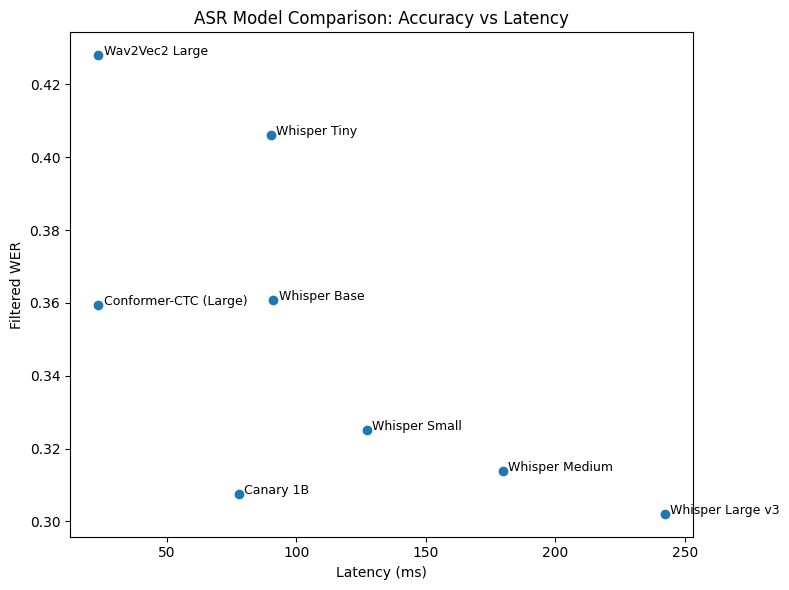

In [21]:
import matplotlib.pyplot as plt

# Prepare data
plot_df = summary.reset_index().copy()

# Keep only non-timestamp models
plot_df = plot_df[plot_df["timestamp_mode"] == "no_timestamps"].copy()

# Apply clean naming
plot_df["model_clean"] = plot_df["model_variant"].apply(clean_model_name)

# ❌ Remove SpeechBrain
plot_df = plot_df[~plot_df["model_clean"].str.contains("SpeechBrain", na=False)]

# Use FILTERED WER
x = plot_df["mean_latency_ms"]
y = plot_df["filtered_wer"]

plt.figure(figsize=(8, 6))

plt.scatter(x, y)

# Labels
for _, row in plot_df.iterrows():
    plt.text(
        row["mean_latency_ms"] + 2,
        row["filtered_wer"],
        row["model_clean"],
        fontsize=9
    )

plt.xlabel("Latency (ms)")
plt.ylabel("Filtered WER")
plt.title("ASR Model Comparison: Accuracy vs Latency")

plt.tight_layout()
plt.show()

In [24]:
thresholds = [0, 10, 20, 40, 60]
rows = []

# start from df_eval since your raw/filtered columns are already prepared there
base_df = df_eval.copy()

for min_chars in thresholds:
    df_len = base_df[base_df["reference_text"].astype(str).str.len() >= min_chars].copy()

    # keep only segments still present for all model variants
    n_variants = df_len["model_variant"].nunique()
    common_segments_len = (
        df_len.groupby("segment_id")["model_variant"]
              .nunique()
              .loc[lambda x: x == n_variants]
              .index
    )
    df_len = df_len[df_len["segment_id"].isin(common_segments_len)].copy()

    temp = (
        df_len.groupby(["model", "timestamp_mode", "model_variant"])
        .apply(lambda g: pd.Series({
            "filtered_wer": wer(g["ref_filtered"].tolist(), g["hyp_filtered"].tolist()),
            "filtered_cer": cer(" ".join(g["ref_filtered"].tolist()), " ".join(g["hyp_filtered"].tolist())),
            "mean_latency_ms": g["latency_ms"].mean(),
            "num_segments": g["segment_id"].count(),
            "min_chars": min_chars,
        }))
        .reset_index()
    )

    rows.append(temp)

threshold_results = pd.concat(rows, ignore_index=True)

threshold_results.head()

,model,timestamp_mode,model_variant,filtered_wer,filtered_cer,mean_latency_ms,num_segments,min_chars
0,canary:nvidia/canary-1b-v2,no_timestamps,canary:nvidia/canary-1b-v2 | no_timestamps,0.301662,0.208842,80.052155,18404.0,0.0
1,conformer_ctc:stt_en_conformer_ctc_large,no_timestamps,conformer_ctc:stt_en_conformer_ctc_large | no_...,0.355934,0.224800,23.751930,18404.0,0.0
2,speechbrain:speechbrain/asr-crdnn-rnnlm-libris...,no_timestamps,speechbrain:speechbrain/asr-crdnn-rnnlm-libris...,0.746086,0.519992,256.009156,18404.0,0.0
3,wav2vec2:facebook/wav2vec2-large-960h-lv60-self,no_timestamps,wav2vec2:facebook/wav2vec2-large-960h-lv60-sel...,0.426147,0.245941,23.824368,18404.0,0.0
4,whisper:base,no_timestamps,whisper:base | no_timestamps,0.357626,0.239698,89.744237,18404.0,0.0
